In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import src.data_loader as data_loader
import src.baseline_model as baseline_model
import src.config as config

# Part 1. Baseline Calculation

In [2]:
DATA_DIR = Path("data/raw")

start = config.EVENT_START
end = config.EVENT_END

all_data = {}
events = {}

for path in sorted(DATA_DIR.iterdir()):
    site = path.stem
    hourly = data_loader.load_site_hourly(path)
    all_data[site] = hourly

    event_df = data_loader.slice_event_hourly(hourly, start, end)
    event_df = baseline_model.build_10of10(hourly, event_df)
    event_df = baseline_model.build_fsl(event_df, config.FSL_KW[site])
    events[site] = event_df

In [3]:
perf_10of10, perf_fsl = {}, {}

for site, event_df in events.items():
    perf_10of10[site] = event_df["10of10_performance"].mean()
    perf_fsl[site] = event_df["fsl_performance"].mean()

### Result Validation

In [4]:
gt = pd.read_csv("data/ref/gt.csv", index_col=0)
gt.columns = gt.columns.str.replace(" ", "_").str.lower()

In [5]:
summary = pd.DataFrame({
    "perf_10of10_kw": perf_10of10,
    "gt_10of10_avg_kw": gt.iloc[0],
    "perf_fsl_kw": perf_fsl,
    "gt_fsl_avg_kw": gt.iloc[1],
}).round(0).astype(int)

summary

,perf_10of10_kw,gt_10of10_avg_kw,perf_fsl_kw,gt_fsl_avg_kw
site_1,3937,3937,3337,3337
site_2,4345,4345,5075,5075
site_3,649,649,850,850
site_5,3500,3500,3235,3235
site_6,-12,-12,41,41


Both baselines are based on historical data at the given site. For each event hour, 10of10 compares actual hourly usage against the average of 10 most recent "similar hour" performance (i.e. same hour of the day, and day is chosen based on the weekend/weekday type that the event day is in). Performance gives a numerical estimate to how much the actual usage deviates from the client's OWN typical use pattern. 
Meanwhile, the FSL performance compares the data to a fixed peak-demand benchmark based on the MISO system. 
Therefore, 10of10 reflects recent operational baseline, whereas FSL reflects a system-level benchmark. 

Note that sometimes 10of10 is higher, but sometimes FSL number is higher. If the customer has been recently using high load, then the 10of10 baseline would increase, making their event reduction look larger. 

In [6]:
summary.to_csv("outputs/performance_summary.csv")

# Part 2.  Data Exploration and Analysis

Time series for all hourly data.

In [20]:
def build_time_series(
    data: dict, 
    plot_window: tuple = None, 
    title: str = None
):
    """
    Builds a time series plot for the given dataframe, start, and end timestamps.
    """

    fig, axes = plt.subplots(len(data), 1, figsize=(12, 2.5*len(data)))
    fig.suptitle(title, fontsize=14)

    sites = list(data.keys())

    for ax, site in zip(axes, sites):
        d = data[site]
        ax.plot(d["timestamp"], d["load_kw"], linewidth=0.7)

        if plot_window is not None:
            ax.set_xlim(plot_window)

        ax.set_title(site)
        ax.set_ylabel("kW")

        ax.axvspan(start, end, color="red", alpha=0.15, label="Event window")

        ax.legend(loc="upper right")
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    fig.savefig(f"outputs/{title}.png", dpi=150, bbox_inches="tight")
    

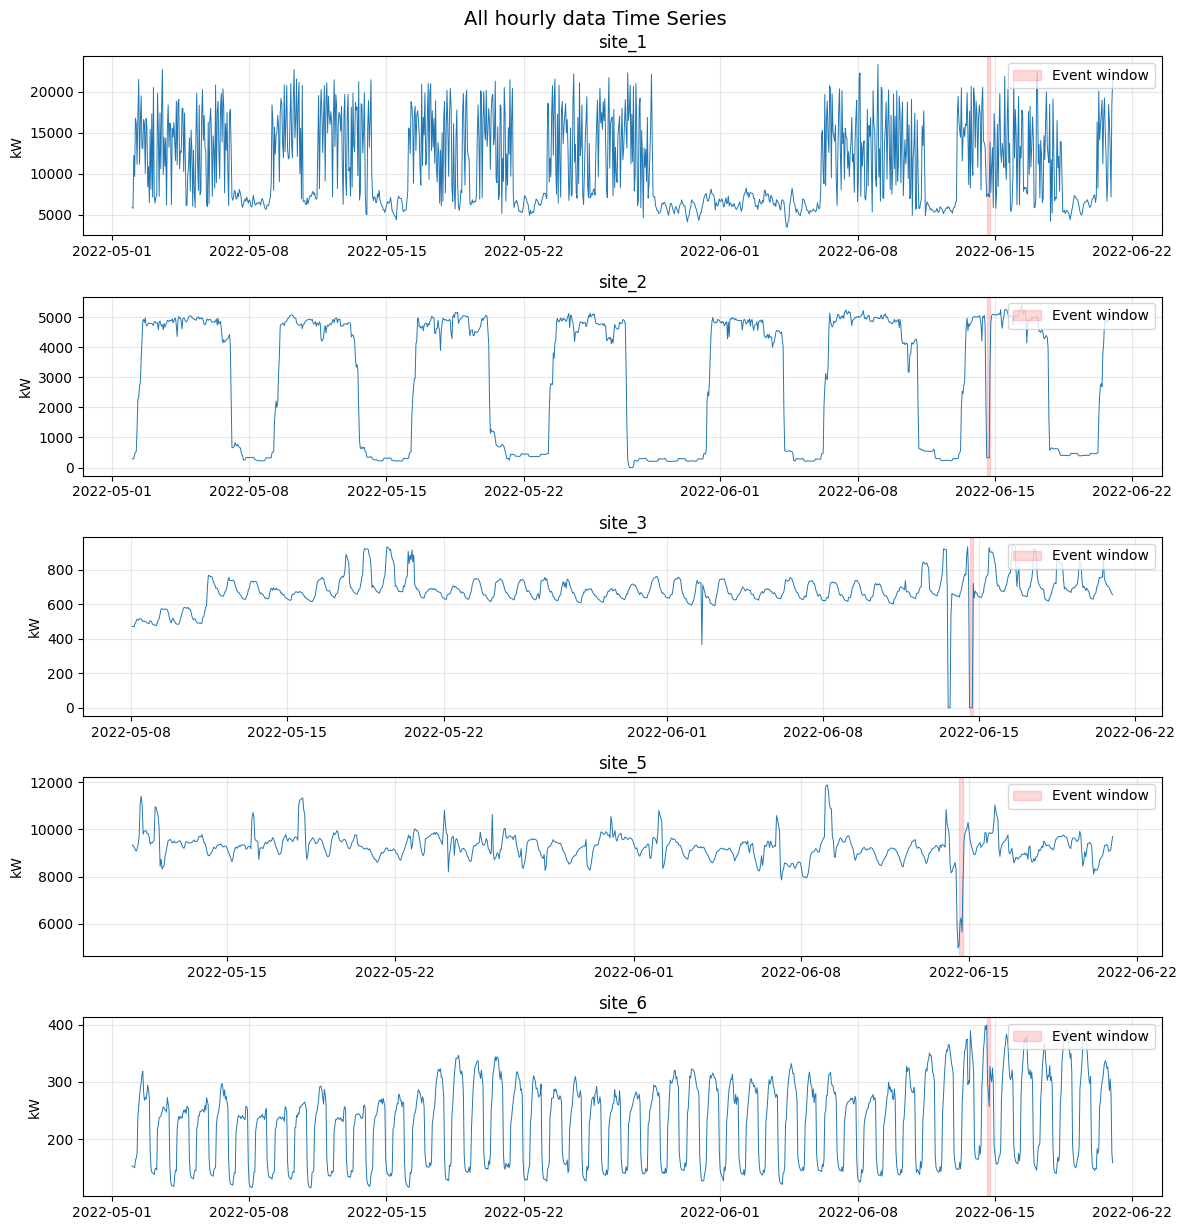

In [21]:
build_time_series(all_data, title = "All hourly data Time Series")

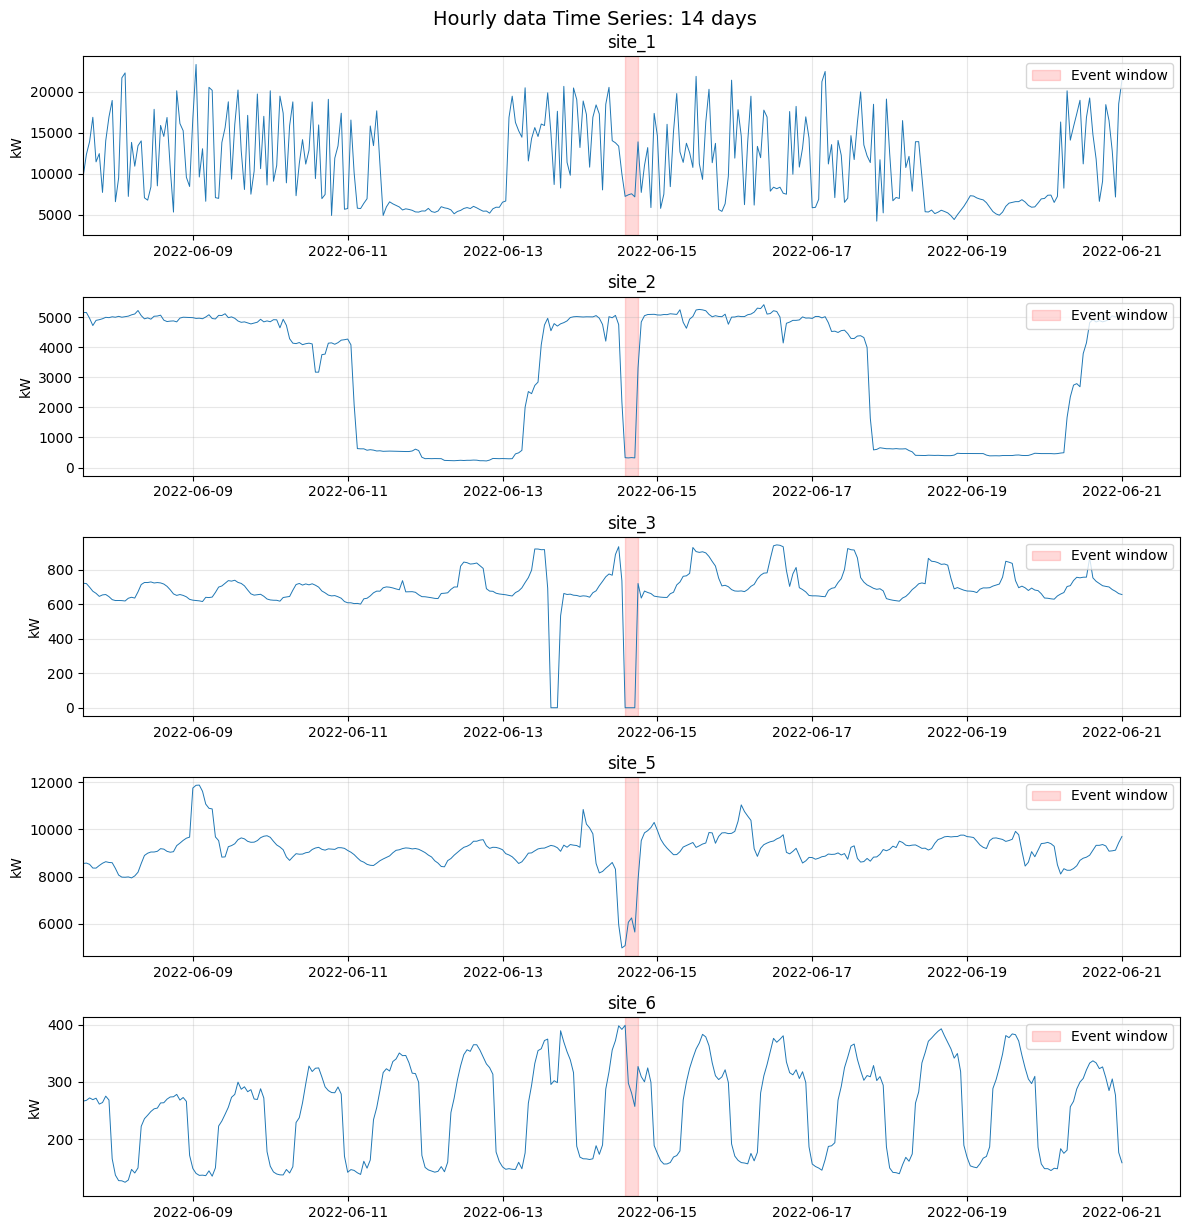

In [22]:
build_time_series(
    all_data, 
    plot_window=(start - pd.Timedelta(days=7), end + pd.Timedelta(days=7)), 
    title = "Hourly data Time Series: 14 days"
)

Strong cyclic patterns; 
- weekly dominate: site 1 and 2
- daily dominate: site 3, 5, and 6

In [25]:
def legend_outside(axes):
    handles, labels = axes[0].get_legend_handles_labels()
    axes[-1].axis("off")
    axes[-1].legend(handles, labels, loc="lower left")


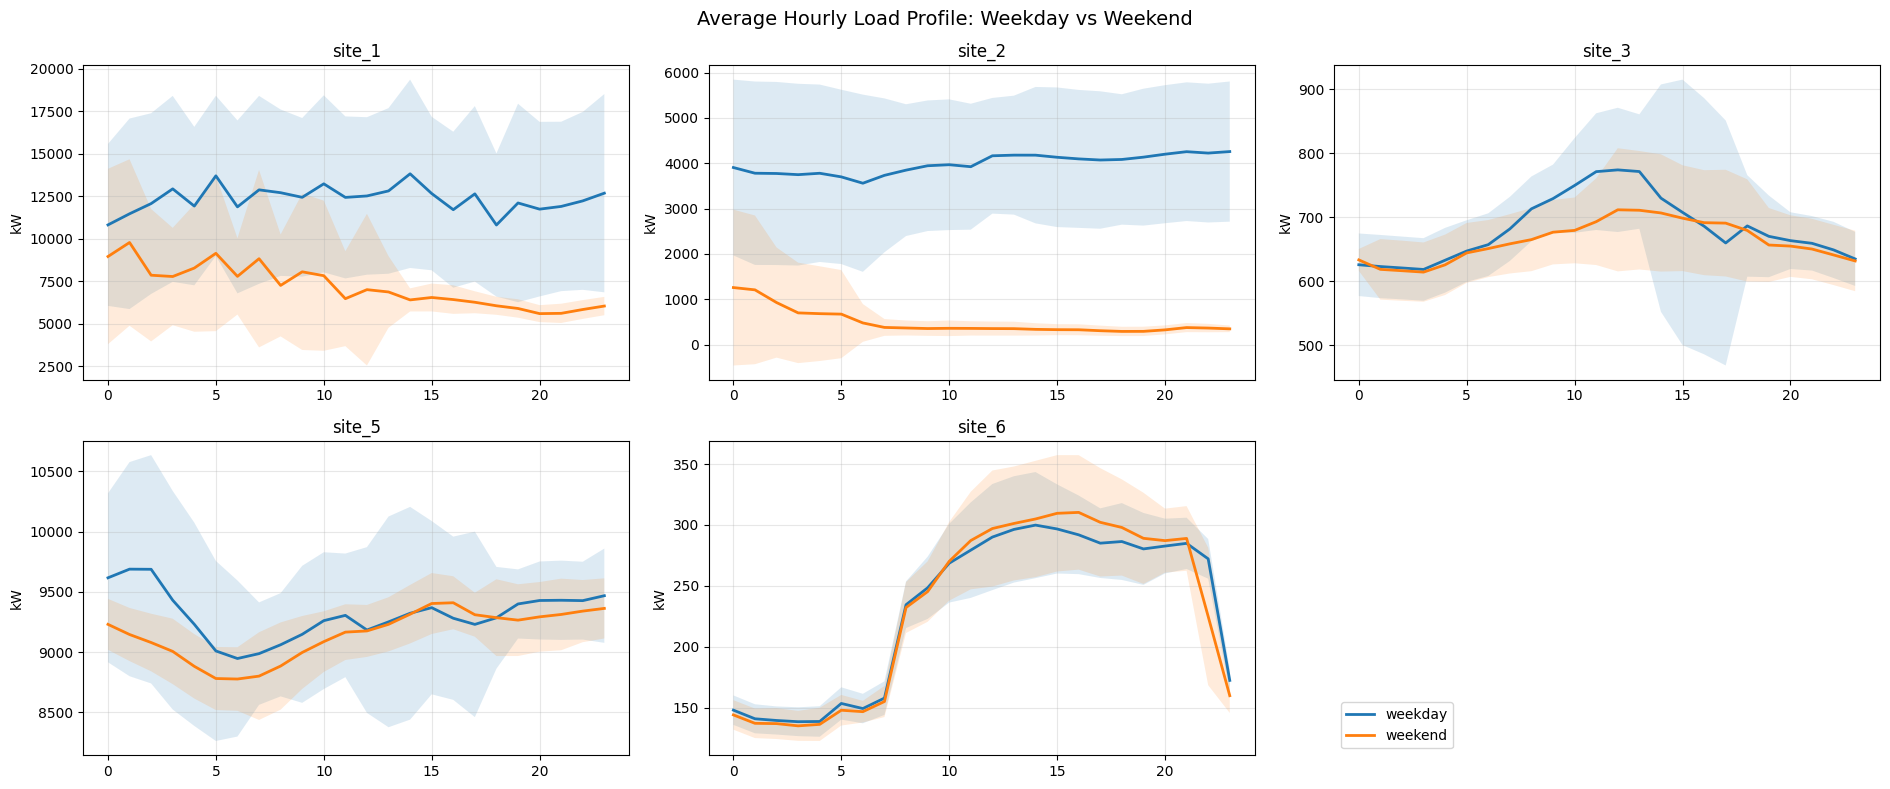

In [34]:
sites = list(all_data.keys())

fig, axes = plt.subplots(2, 3, figsize=(19,8))
fig.suptitle("Average Hourly Load Profile: Weekday vs Weekend", fontsize=14)
axes = axes.ravel()

for ax, site in zip(axes, sites):
    df = all_data[site]
    df["hour"] = df["timestamp"].dt.hour
    df["daytype"] = np.where(df["timestamp"].dt.weekday >= 5, "weekend", "weekday")
    
    grouped = df.groupby(["daytype", "hour"])["load_kw"]
    profile = grouped.agg(mean="mean", std="std").reset_index()

    plt.sca(ax)

    for daytype in ["weekday", "weekend"]:
        p = profile[profile["daytype"] == daytype].sort_values("hour")
        plt.plot(p["hour"], p["mean"], label=daytype, linewidth=2)
        #plot standard deviation as shaded area 
        plt.fill_between(p["hour"], p["mean"] - p["std"], 
                         p["mean"] + p["std"], alpha=0.15)

    plt.ylabel("kW")
    plt.title(site)
    plt.grid(True, alpha=0.3)

legend_outside(axes)

plt.tight_layout()
plt.show()

# fig.savefig("outputs/weekday_vs_weekend.png", dpi=150, bbox_inches="tight")

In [11]:
site_stats = pd.DataFrame(index=sites)

for site, d in all_data.items():
    d = d[(d["timestamp"] < start) | (d["timestamp"] >= end)]
    weekday = d[d["timestamp"].dt.weekday < 5]["load_kw"]
    weekend = d[d["timestamp"].dt.weekday >= 5]["load_kw"]
    site_stats.loc[site, "mean_kw"] = d["load_kw"].mean()
    site_stats.loc[site, "wknd_wkday_ratio"] = weekend.mean() / weekday.mean()
    site_stats.loc[site, "wkday_p95_kw"] = weekday.quantile(0.95)
    site_stats.loc[site, "wkday_p5_kw"] = weekday.quantile(0.05)
    site_stats.loc[site, "wknd_p95_kw"] = weekend.quantile(0.95)
    site_stats.loc[site, "wknd_p5_kw"] = weekend.quantile(0.05)

site_stats["wkday_pb_ratio"] = site_stats["wkday_p95_kw"] / site_stats["wkday_p5_kw"]
site_stats["wknd_pb_ratio"] = site_stats["wknd_p95_kw"] / site_stats["wknd_p5_kw"]


site_stats.round(2)

,mean_kw,wknd_wkday_ratio,wkday_p95_kw,wkday_p5_kw,wknd_p95_kw,wknd_p5_kw,wkday_pb_ratio,wknd_pb_ratio
site_1,10907.78,0.58,20455.74,5917.86,15606.00,5011.20,3.46,3.11
site_2,3015.03,0.12,5094.18,291.42,726.30,208.80,17.48,3.48
site_3,678.54,0.97,877.32,533.52,822.60,503.64,1.64,1.63
site_5,9277.18,0.98,10423.16,8367.02,9690.77,8607.76,1.25,1.13
site_6,230.58,1.00,333.18,132.11,353.88,126.32,2.52,2.80


<Figure size 800x500 with 0 Axes>

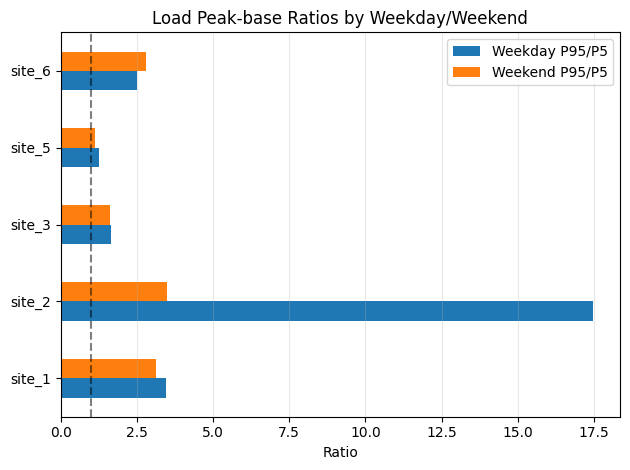

In [27]:
plt.figure(figsize=(8, 5))
site_stats[["wkday_pb_ratio", "wknd_pb_ratio"]].rename(columns={
    "wkday_pb_ratio": "Weekday P95/P5",
    "wknd_pb_ratio": "Weekend P95/P5",
}).plot(kind="barh")

plt.axvline(1, ls="--", c="k", alpha=0.5)
plt.xlabel("Ratio")
plt.title("Load Peak-base Ratios by Weekday/Weekend")
plt.grid(True, alpha=0.3, axis="x")
plt.legend(loc="upper right")
plt.tight_layout()

Site 2 Anomaly: unusually large weekday ratio. Possibly due to off-days, outages, or missing data being filled as 0. Might want to further investigate if given more time. 

## During Event 

Event day vs average weekday

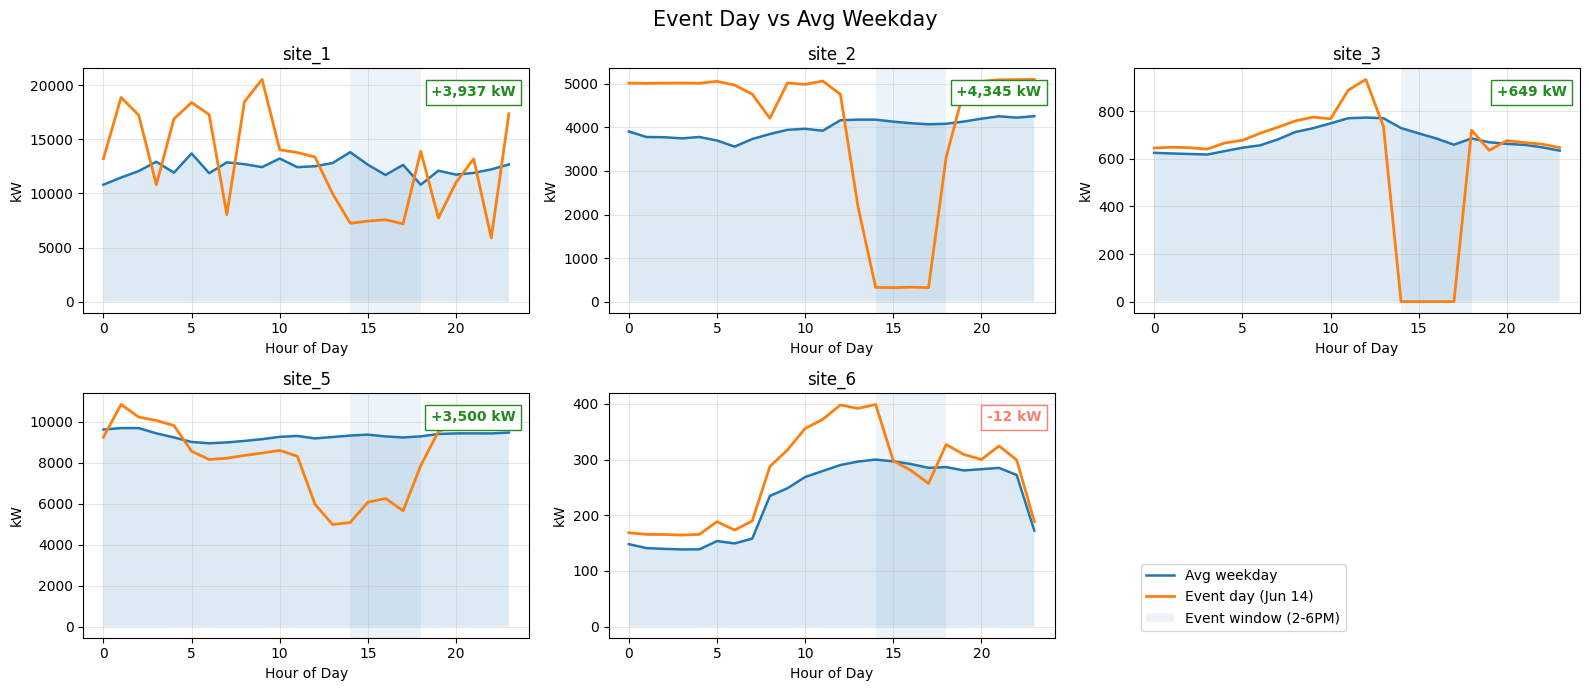

In [37]:
fig, axes = plt.subplots(2, 3, figsize=(16, 7))
axes = axes.ravel()

fig.suptitle("Event Day vs Avg Weekday", fontsize=15)

event_date = start.normalize()
event_end = event_date + pd.Timedelta(days=1)

for ax, site in zip(axes, sites):
    df = all_data[site].copy()
    df["hour"] = df["timestamp"].dt.hour

    wkday_mean = df[df["timestamp"].dt.weekday < 5].groupby("hour")["load_kw"].mean()

    event_day = df[(df["timestamp"] >= event_date) & (df["timestamp"] < event_end)]

    plt.sca(ax)

    plt.fill_between(wkday_mean.index, wkday_mean, alpha=0.15)
    plt.plot(wkday_mean.index, wkday_mean, label="Avg weekday", linewidth=1.8)

    plt.plot(event_day["hour"], event_day["load_kw"], label="Event day (Jun 14)", linewidth=2)

    plt.axvspan(14, 18, alpha=0.08, label="Event window (2-6PM)")

    perf = perf_10of10.get(site, 0)
    badge = f"{perf:+,.0f} kW" if perf >= 0 else f"{perf:,.0f} kW"
    color = "forestgreen" if perf > 0 else "salmon"
    plt.text(
        0.97, 0.93, badge, transform=ax.transAxes,
        fontweight="bold", color=color, ha="right", va="top",
        bbox=dict(fc="white", ec=color),
    )

    plt.title(site)
    plt.ylabel("kW")
    plt.xlabel("Hour of Day")
    plt.grid(True, alpha=0.3)

legend_outside(axes)

plt.tight_layout()
plt.show()

## Site 2 Deep Dive

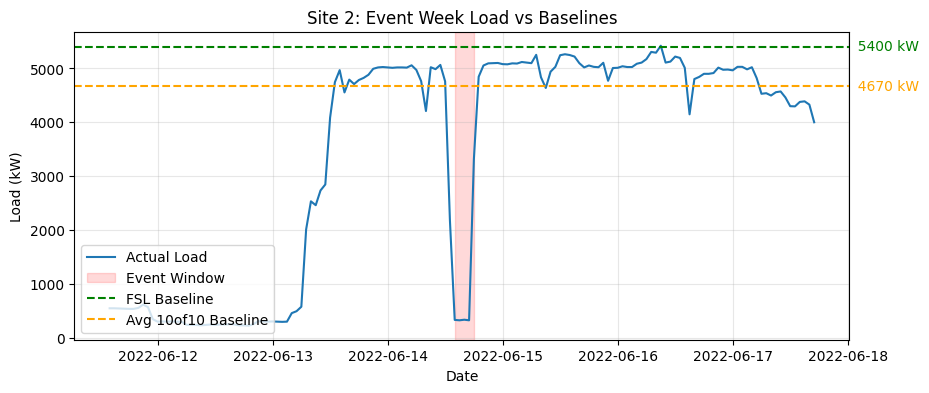

In [40]:
site = "site_2"
df = all_data[site]
ev = events[site]

fsl = config.FSL_KW[site]
tenoften = ev["10of10_baseline"].mean()

window_start = start - pd.Timedelta(days=3)
window_end = end + pd.Timedelta(days=3)
zoom = df[(df["timestamp"] >= window_start) & (df["timestamp"] < window_end)]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(zoom["timestamp"], zoom["load_kw"], label="Actual Load")
ax.axvspan(start, end, color="red", alpha=0.15, label="Event Window")
ax.axhline(y=fsl, color="green", linestyle="--", 
            label="FSL Baseline")
ax.text(ax.get_xlim()[1], fsl, f"  {fsl} kW", 
        va="center", color="green")
        
ax.axhline(y=tenoften, color="orange", linestyle="--", 
            label="Avg 10of10 Baseline")
ax.text(ax.get_xlim()[1], tenoften, f"  {tenoften:.0f} kW", 
        va="center", color="orange")

ax.set(xlabel="Date", ylabel="Load (kW)", 
       title="Site 2: Event Week Load vs Baselines")
ax.legend(loc="lower left")
ax.grid(alpha=0.3)

# fig.savefig("outputs/site2_event_week.png", dpi=150)
plt.show()

# Part 3. Financial Results

In [15]:
lmp = {pd.Timestamp(k): v for k, v in config.LMP.items()}

In [16]:
for site, event_df in events.items():
    event_df['LMP'] = event_df["timestamp"].map(lmp)
    event_df['customer_share'] = config.REVENUE_SHARE[site]

    # KEY ASSUMPTION: negative hourly performance was floored at 0 kW 
    # i.e. no financial penalty for underperformance 
    event_df['perf_to_pay'] = event_df['10of10_performance'].clip(lower=0)
    event_df['gross_rev'] = event_df['perf_to_pay'] * event_df['LMP'] / 1000.0
    event_df['cogs'] = event_df['gross_rev'] * event_df['customer_share']
    event_df['profit'] = event_df['gross_rev'] - event_df['cogs']

In [17]:
summary = pd.DataFrame({
    site: {
        "Gross Revenue ($)": df["gross_rev"].sum(),
        "COGS ($)": df["cogs"].sum(),
        "Profit ($)": df["profit"].sum(),
    }
    for site, df in events.items()
}).T

In [18]:
summary.round(0)  

,Gross Revenue ($),COGS ($),Profit ($)
site_1,24217.0,15499.0,8718.0
site_2,30770.0,19077.0,11693.0
site_3,4600.0,2576.0,2024.0
site_5,23873.0,15518.0,8356.0
site_6,71.0,36.0,35.0


In [19]:
summary.to_csv("outputs/financial_summary.csv")